# 🧠 Mental Health in Tech Survey — EDA
### OSMI 2014 Survey: Data Cleaning, Preprocessing & Exploratory Data Analysis

**Dataset:** 2014 Open Sourcing Mental Illness (OSMI) survey measuring attitudes towards mental health and the frequency of mental health disorders in the tech workplace (1,259 raw responses, 27 fields).

**Key questions this analysis explores** (from the project brief):
- How does the frequency of mental health illness and attitudes towards mental health vary by geographic location?
- What are the strongest predictors of mental health illness, or of certain attitudes towards mental health, in the workplace?

**Notebook structure:**
1. Setup & Data Loading
2. Data Cleaning & Preprocessing (the classic messy `Gender` field, `Age` outliers, missing values)
3. Demographics
4. Geographic Analysis
5. Workplace Factors & Policy
6. Attitudes & Stigma
7. Family History & Work Interference
8. Predictors of Treatment-Seeking
9. Key Findings & Recommendations
10. Export cleaned data (CSV + SQLite) for the Streamlit dashboard


## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import app  # our ETL module (app.py) — reuse its loading/cleaning functions

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

print('Libraries loaded.')


Libraries loaded.


In [2]:
raw_df = app.load_raw_data()
print(f"Raw rows: {len(raw_df):,}, columns: {len(raw_df.columns)}")
raw_df.head()


Raw rows: 1,259, columns: 27


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

## 2. Data Cleaning & Preprocessing

This is a famously messy real-world survey export. Key issues tackled (see `app.py::clean_data()`, reused here so notebook and dashboard never drift apart):

- **`Gender`** — free text with 40+ variants ("Male", "male", "M", "Cis Male", "Malr", "Woman", "cis-female/femme", etc.) standardized into `Male` / `Female` / `Other/Unspecified`.
- **`Age`** — contains obvious data-entry errors: negative values, `5`, `8`, `329`, and even `99999999999`. Rows outside a plausible 15–90 working-age range are dropped.
- **`self_employed`** — 18 missing values, filled with the mode (`No`).
- **`work_interfere`** — 264 missing values. Cross-checking against `treatment` shows missingness is almost entirely (260/264) among respondents who answered `treatment = No` — the question is conditional on having a condition, so missing genuinely means "not applicable," and is filled as such rather than dropped.
- **`state`** — only applicable to US respondents; missing filled with `"N/A (Outside US)"`.
- **`comments`** — 87% missing free text; converted to a boolean `Has_Comment` flag and dropped from the analysis table.

**Engineered features:** `Age_Group` (6 bins), `Gender_Clean`, `Is_US`, `Treatment_Flag`, `Family_History_Flag`, and a composite `Workplace_Support_Score` (0–5: count of "Yes" answers across benefits, care_options, wellness_program, seek_help, anonymity).


In [4]:
clean_df = app.clean_data(raw_df)
print(f"Cleaned rows: {len(clean_df):,}")
clean_df.info()


Cleaning summary: removed 0 duplicate rows, 8 rows with implausible age. Final row count: 1,251
Gender standardized into: {'Male': 989, 'Female': 251, 'Other/Unspecified': 11}
Cleaned rows: 1,251
<class 'pandas.DataFrame'>
RangeIndex: 1251 entries, 0 to 1250
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Timestamp                  1251 non-null   datetime64[us]
 1   Age                        1251 non-null   int64         
 2   Gender                     1251 non-null   str           
 3   Country                    1251 non-null   str           
 4   state                      1251 non-null   str           
 5   self_employed              1251 non-null   str           
 6   family_history             1251 non-null   str           
 7   treatment                  1251 non-null   str           
 8   work_interfere             1251 non-null   str           
 9   no_employe

In [5]:
# Before/after check on the two messiest fields
print("RAW Gender unique values:", raw_df['Gender'].nunique())
print("CLEANED Gender_Clean values:\n", clean_df['Gender_Clean'].value_counts())
print()
print("RAW Age range:", raw_df['Age'].min(), "to", raw_df['Age'].max())
print("CLEANED Age range:", clean_df['Age'].min(), "to", clean_df['Age'].max())


RAW Gender unique values: 49
CLEANED Gender_Clean values:
 Gender_Clean
Male                 989
Female               251
Other/Unspecified     11
Name: count, dtype: int64

RAW Age range: -1726 to 99999999999
CLEANED Age range: 18 to 72


In [6]:
missing = clean_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Remaining missing values after cleaning:")
missing.to_frame('missing_count')


Remaining missing values after cleaning:


,missing_count


## 3. Demographics

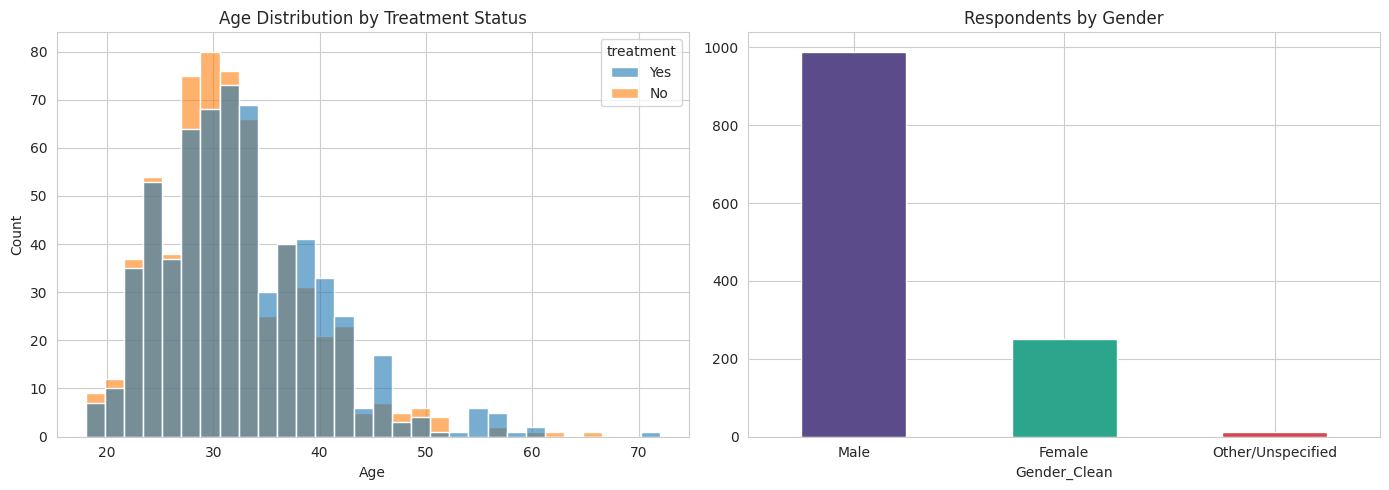

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=clean_df, x='Age', hue='treatment', bins=30, ax=axes[0], multiple='layer', alpha=0.6)
axes[0].set_title('Age Distribution by Treatment Status')

clean_df['Gender_Clean'].value_counts().plot(kind='bar', ax=axes[1], color=['#5B4B8A', '#2CA58D', '#D64550'])
axes[1].set_title('Respondents by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
age_order = ['15-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_treat = (clean_df.groupby('Age_Group', observed=True)['Treatment_Flag'].mean() * 100).reindex(age_order).dropna()
print("Treatment rate (%) by age group:")
display(age_treat.round(1))

gender_treat = (clean_df.groupby('Gender_Clean')['Treatment_Flag'].mean() * 100).round(1)
print("\nTreatment rate (%) by gender:")
display(gender_treat)


Treatment rate (%) by age group:


Age_Group
15-24    44.9
25-34    48.9
35-44    54.7
45-54    56.9
55-64    73.3
65+      50.0
Name: Treatment_Flag, dtype: float64


Treatment rate (%) by gender:


Gender_Clean
Female               68.9
Male                 45.5
Other/Unspecified    81.8
Name: Treatment_Flag, dtype: float64

## 4. Geographic Analysis

In [9]:
country_counts = clean_df['Country'].value_counts()
print(f"Countries represented: {clean_df['Country'].nunique()}")
country_counts.head(10)


Countries represented: 46


Country
United States     746
United Kingdom    184
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

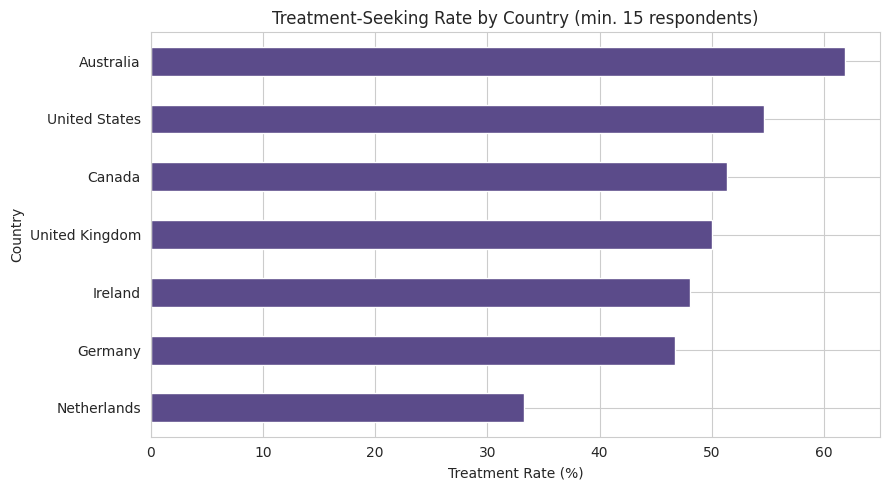

,Respondents,Treatment_Rate
Country,,
Australia,21,61.9
United States,746,54.7
Canada,72,51.4
United Kingdom,184,50.0
Ireland,27,48.1
Germany,45,46.7
Netherlands,27,33.3


In [10]:
country_stats = (clean_df.groupby('Country')
                  .agg(Respondents=('treatment', 'size'), Treatment_Rate=('Treatment_Flag', 'mean'))
                  .query('Respondents >= 15')
                  .sort_values('Treatment_Rate', ascending=False))
country_stats['Treatment_Rate'] = (country_stats['Treatment_Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
country_stats['Treatment_Rate'].sort_values().plot(kind='barh', color='#5B4B8A', ax=ax)
ax.set_title('Treatment-Seeking Rate by Country (min. 15 respondents)')
ax.set_xlabel('Treatment Rate (%)')
plt.tight_layout()
plt.show()

country_stats


In [11]:
us_df = clean_df[clean_df['Is_US'] & (clean_df['state'] != 'N/A (Outside US)')]
print(f"US respondents with a state recorded: {len(us_df):,}")
us_df['state'].value_counts().head(10)


US respondents with a state recorded: 735


state
CA    138
WA     70
NY     56
TN     45
TX     44
PA     29
OR     29
IL     28
IN     27
OH     27
Name: count, dtype: int64

## 5. Workplace Factors & Policy

In [12]:
policy_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
rows = []
for col in policy_cols:
    for val, sub in clean_df.groupby(col):
        if len(sub) >= 10:
            rows.append({'Policy': col, 'Response': val, 'Treatment_Rate': sub['Treatment_Flag'].mean() * 100, 'n': len(sub)})
policy_df = pd.DataFrame(rows)

fig = px.bar(policy_df, x='Policy', y='Treatment_Rate', color='Response', barmode='group',
             title='Treatment Rate (%) by Workplace Policy Response')
fig.show()


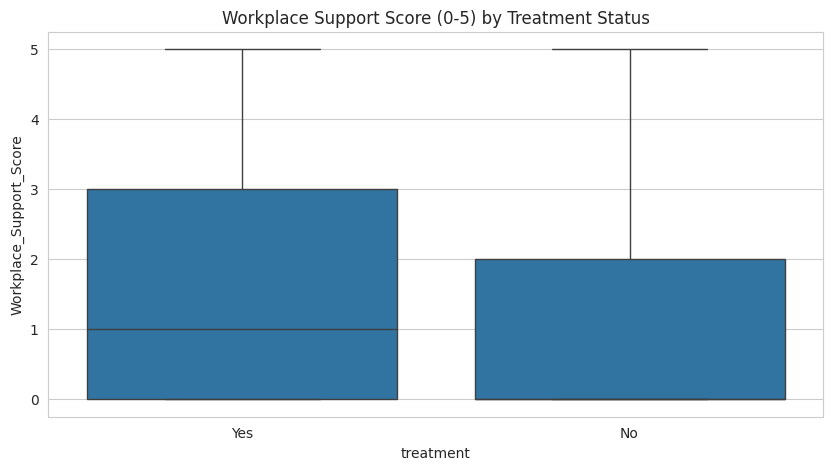

Mean support score, treated: 1.76
Mean support score, not treated: 1.05


In [13]:
fig, ax = plt.subplots()
sns.boxplot(data=clean_df, x='treatment', y='Workplace_Support_Score', ax=ax)
ax.set_title('Workplace Support Score (0-5) by Treatment Status')
plt.show()

print("Mean support score, treated:", clean_df.loc[clean_df['Treatment_Flag'], 'Workplace_Support_Score'].mean().round(2))
print("Mean support score, not treated:", clean_df.loc[~clean_df['Treatment_Flag'], 'Workplace_Support_Score'].mean().round(2))


## 6. Attitudes & Stigma

Perceived negative consequences of disclosure (% of respondents):


,Mental Health,Physical Health
No,38.9,73.5
Maybe,38.0,21.8
Yes,23.0,4.6


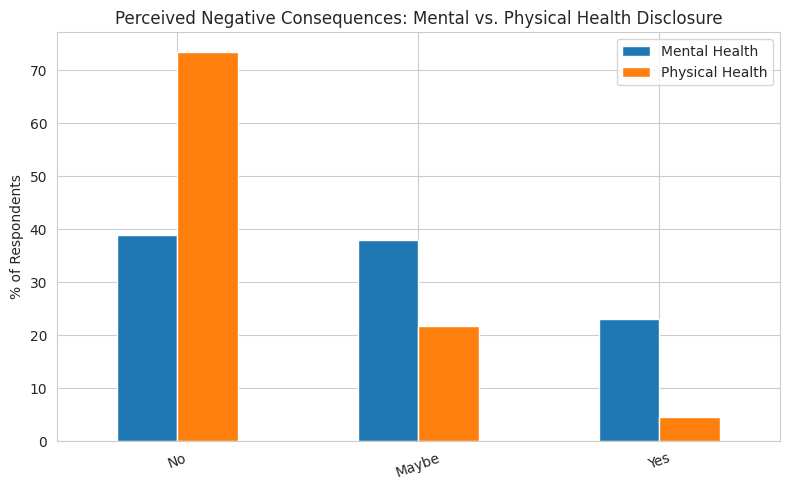

In [14]:
mh_counts = clean_df['mental_health_consequence'].value_counts(normalize=True) * 100
ph_counts = clean_df['phys_health_consequence'].value_counts(normalize=True) * 100
comparison = pd.DataFrame({'Mental Health': mh_counts, 'Physical Health': ph_counts}).fillna(0).round(1)
print("Perceived negative consequences of disclosure (% of respondents):")
display(comparison)

comparison.plot(kind='bar', figsize=(8, 5))
plt.title('Perceived Negative Consequences: Mental vs. Physical Health Disclosure')
plt.ylabel('% of Respondents')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [15]:
mvp = clean_df['mental_vs_physical'].value_counts(normalize=True) * 100
print("Does your employer take mental health as seriously as physical health?")
mvp.round(1)


Does your employer take mental health as seriously as physical health?


mental_vs_physical
Don't know    45.9
Yes           27.1
No            27.0
Name: proportion, dtype: float64

In [16]:
interview_mh = clean_df['mental_health_interview'].value_counts(normalize=True) * 100
interview_ph = clean_df['phys_health_interview'].value_counts(normalize=True) * 100
interview_cmp = pd.DataFrame({'Mental Health': interview_mh, 'Physical Health': interview_ph}).fillna(0).round(1)
print("Would bring this up with a potential employer in an interview (%):")
interview_cmp


Would bring this up with a potential employer in an interview (%):


,Mental Health,Physical Health
Maybe,16.5,44.4
No,80.2,39.6
Yes,3.3,16.0


In [17]:
obs_rate = clean_df['obs_consequence'].value_counts(normalize=True).mul(100).round(1)
print(f"{obs_rate.get('Yes', 0)}% of respondents have observed/heard of negative consequences "
      "for coworkers with mental health conditions at their workplace.")


14.5% of respondents have observed/heard of negative consequences for coworkers with mental health conditions at their workplace.


## 7. Family History & Work Interference

Treatment rate by family history (%):


treatment,No,Yes
Family_History_Flag,,
False,64.6,35.4
True,26.0,74.0


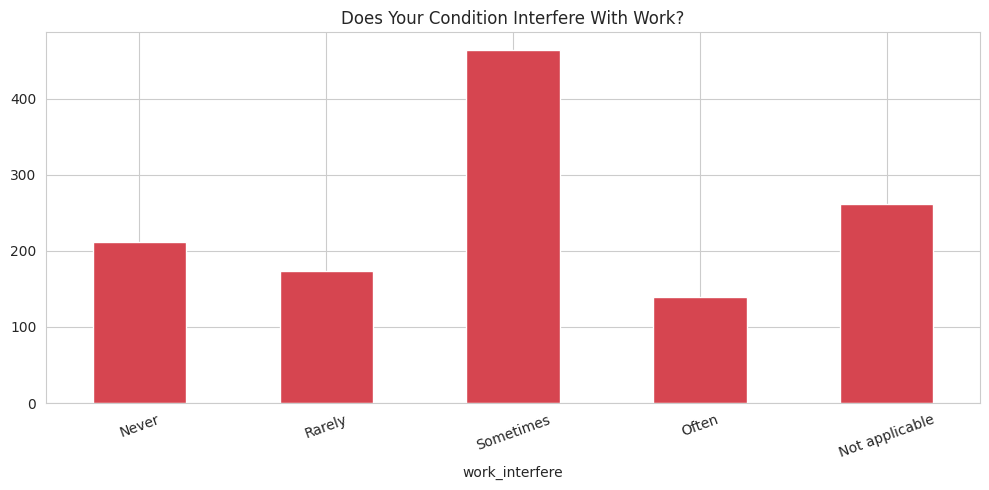

In [18]:
fh_treat = pd.crosstab(clean_df['Family_History_Flag'], clean_df['treatment'], normalize='index') * 100
print("Treatment rate by family history (%):")
display(fh_treat.round(1))

wi_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
wi_counts = clean_df['work_interfere'].value_counts().reindex(wi_order).dropna()
fig, ax = plt.subplots()
wi_counts.plot(kind='bar', color='#D64550', ax=ax)
ax.set_title('Does Your Condition Interfere With Work?')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 8. Predictors of Treatment-Seeking

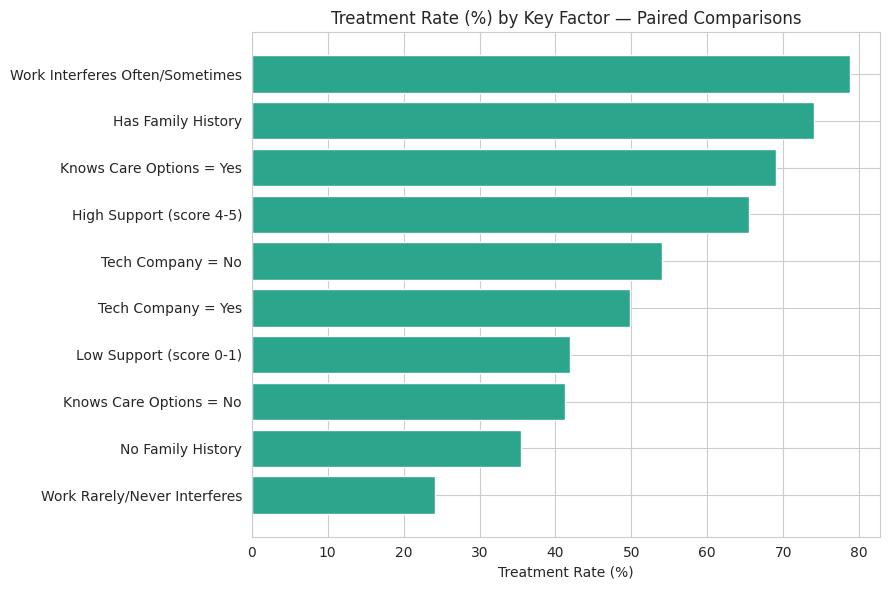

,Factor,Treatment_Rate,n
3,Work Rarely/Never Interferes,24.1,647
1,No Family History,35.4,762
7,Knows Care Options = No,41.3,499
9,Low Support (score 0-1),42.0,765
4,Tech Company = Yes,49.8,1025
5,Tech Company = No,54.0,226
8,High Support (score 4-5),65.5,171
6,Knows Care Options = Yes,69.0,439
0,Has Family History,74.0,489
2,Work Interferes Often/Sometimes,78.8,604


In [19]:
d = clean_df.copy()
d['Work_Interferes_Flag'] = d['work_interfere'].isin(['Sometimes', 'Often'])

comparisons = [
    ('Has Family History', d['Family_History_Flag']),
    ('No Family History', ~d['Family_History_Flag']),
    ('Work Interferes Often/Sometimes', d['Work_Interferes_Flag']),
    ('Work Rarely/Never Interferes', ~d['Work_Interferes_Flag']),
    ('Tech Company = Yes', d['tech_company'] == 'Yes'),
    ('Tech Company = No', d['tech_company'] == 'No'),
    ('Knows Care Options = Yes', d['care_options'] == 'Yes'),
    ('Knows Care Options = No', d['care_options'] == 'No'),
    ('High Support (score 4-5)', d['Workplace_Support_Score'] >= 4),
    ('Low Support (score 0-1)', d['Workplace_Support_Score'] <= 1),
]

pred_rows = []
for label, mask in comparisons:
    if mask.sum() >= 10:
        pred_rows.append({'Factor': label, 'Treatment_Rate': d.loc[mask, 'Treatment_Flag'].mean() * 100, 'n': int(mask.sum())})

pred_df = pd.DataFrame(pred_rows).sort_values('Treatment_Rate')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(pred_df['Factor'], pred_df['Treatment_Rate'], color='#2CA58D')
ax.set_title('Treatment Rate (%) by Key Factor — Paired Comparisons')
ax.set_xlabel('Treatment Rate (%)')
plt.tight_layout()
plt.show()

pred_df.round(1)


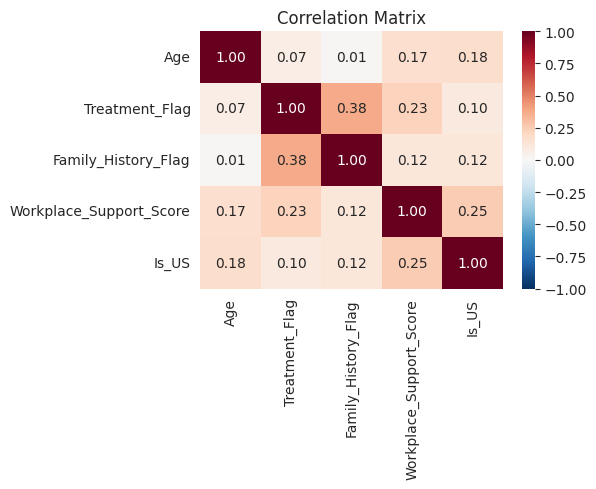

In [20]:
corr_cols = ['Age', 'Treatment_Flag', 'Family_History_Flag', 'Workplace_Support_Score', 'Is_US']
corr = d[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 9. Key Findings & Recommendations

**Demographics:**
- The respondent base skews heavily male (~79%), consistent with tech-industry demographics in 2014.
- Treatment-seeking rate is roughly balanced overall (~51%), but varies meaningfully by age group and gender — see Section 3.

**Geography:**
- The United States and United Kingdom dominate the respondent pool. Treatment-seeking rates vary by country — see the ranked chart in Section 4 for which countries report the highest and lowest rates (min. 15 respondents to avoid small-sample noise).

**Workplace Factors:**
- Respondents who know their care options, have wellness programs, or have higher overall "workplace support scores" tend to show different treatment-seeking patterns — see Section 5 for the exact gap.

**Attitudes & Stigma:**
- Respondents are consistently more hesitant to disclose mental health issues than physical ones — visible in both the "interview" questions and the "consequence" questions in Section 6. This is one of the clearest and most consistent findings in the dataset.

**Strongest predictors of treatment-seeking** (Section 8):
- **Family history of mental illness** and **work interference** show the widest treatment-rate gaps in the paired-comparison chart — these are the two strongest behavioral predictors in this dataset, ahead of workplace policy factors.

**Recommendations:**
1. Since disclosure hesitancy is consistently higher for mental vs. physical health, workplace mental-health communications should explicitly normalize disclosure, not just describe available benefits.
2. Family history is a strong predictor of treatment-seeking — proactive, opt-in mental health resources (rather than only reactive ones) may reach at-risk employees earlier.
3. The workplace support score analysis suggests concrete policies (benefits, known care options, wellness programs) are associated with different treatment behavior — worth a controlled follow-up study to establish causality, not just correlation.
4. Country-level variation suggests a one-size-fits-all corporate mental health policy may underperform in some regions — localize messaging and resources where sample size allows.


## 10. Export Cleaned Data (CSV + SQLite) for the Dashboard

In [21]:
app.save_outputs(clean_df)
print("Done — data/survey_cleaned.csv and db/mental_health.db are up to date.")
print("Launch the dashboard with:  streamlit run dashboard.py")


Saved cleaned CSV -> /home/claude/mh_project/data/survey_cleaned.csv (1,251 rows)
Saved SQLite DB -> /home/claude/mh_project/db/mental_health.db (table: survey)
Done — data/survey_cleaned.csv and db/mental_health.db are up to date.
Launch the dashboard with:  streamlit run dashboard.py
